<a href="https://colab.research.google.com/github/aysutnyva/Machine_Learning/blob/main/Covid_19_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Covid 19 Dataset

In [719]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [720]:
covid=pd.read_csv('/content/covid_19_data.csv')

In [721]:
covid.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [722]:
covid.shape

(6722, 8)

In [723]:
len(covid)

6722

In [724]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6722 entries, 0 to 6721
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SNo              6722 non-null   int64  
 1   ObservationDate  6722 non-null   object 
 2   Province/State   3953 non-null   object 
 3   Country/Region   6722 non-null   object 
 4   Last Update      6722 non-null   object 
 5   Confirmed        6722 non-null   float64
 6   Deaths           6722 non-null   float64
 7   Recovered        6722 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 420.3+ KB


## Data Cleaning

In [725]:
covid.columns

Index(['SNo', 'ObservationDate', 'Province/State', 'Country/Region',
       'Last Update', 'Confirmed', 'Deaths', 'Recovered'],
      dtype='object')

In [726]:
covid.columns = [col.lower().replace(' ', '-').replace('/', '-') for col in covid.columns]

In [727]:
covid.columns.str.lower().str.replace('/','_').str.replace(' ','_')

Index(['sno', 'observationdate', 'province-state', 'country-region',
       'last-update', 'confirmed', 'deaths', 'recovered'],
      dtype='object')

In [728]:
covid.columns

Index(['sno', 'observationdate', 'province-state', 'country-region',
       'last-update', 'confirmed', 'deaths', 'recovered'],
      dtype='object')

In [729]:
covid.head(10)

,sno,observationdate,province-state,country-region,last-update,confirmed,deaths,recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
5,6,01/22/2020,Guangdong,Mainland China,1/22/2020 17:00,26.0,0.0,0.0
6,7,01/22/2020,Guangxi,Mainland China,1/22/2020 17:00,2.0,0.0,0.0
7,8,01/22/2020,Guizhou,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
8,9,01/22/2020,Hainan,Mainland China,1/22/2020 17:00,4.0,0.0,0.0
9,10,01/22/2020,Hebei,Mainland China,1/22/2020 17:00,1.0,0.0,0.0


In [730]:
covid['country-region'].unique()

array(['Mainland China', 'Hong Kong', 'Macau', 'Taiwan', 'US', 'Japan',
       'Thailand', 'South Korea', 'Singapore', 'Philippines', 'Malaysia',
       'Vietnam', 'Australia', 'Mexico', 'Brazil', 'Colombia', 'France',
       'Nepal', 'Canada', 'Cambodia', 'Sri Lanka', 'Ivory Coast',
       'Germany', 'Finland', 'United Arab Emirates', 'India', 'Italy',
       'UK', 'Russia', 'Sweden', 'Spain', 'Belgium', 'Others', 'Egypt',
       'Iran', 'Israel', 'Lebanon', 'Iraq', 'Oman', 'Afghanistan',
       'Bahrain', 'Kuwait', 'Austria', 'Algeria', 'Croatia',
       'Switzerland', 'Pakistan', 'Georgia', 'Greece', 'North Macedonia',
       'Norway', 'Romania', 'Denmark', 'Estonia', 'Netherlands',
       'San Marino', ' Azerbaijan', 'Belarus', 'Iceland', 'Lithuania',
       'New Zealand', 'Nigeria', 'North Ireland', 'Ireland', 'Luxembourg',
       'Monaco', 'Qatar', 'Ecuador', 'Azerbaijan', 'Czech Republic',
       'Armenia', 'Dominican Republic', 'Indonesia', 'Portugal',
       'Andorra', 'Latvia

In [731]:
covid['country-region']=covid['country-region'].str.lower().str.strip()

In [732]:
covid['country-region'].unique()

array(['mainland china', 'hong kong', 'macau', 'taiwan', 'us', 'japan',
       'thailand', 'south korea', 'singapore', 'philippines', 'malaysia',
       'vietnam', 'australia', 'mexico', 'brazil', 'colombia', 'france',
       'nepal', 'canada', 'cambodia', 'sri lanka', 'ivory coast',
       'germany', 'finland', 'united arab emirates', 'india', 'italy',
       'uk', 'russia', 'sweden', 'spain', 'belgium', 'others', 'egypt',
       'iran', 'israel', 'lebanon', 'iraq', 'oman', 'afghanistan',
       'bahrain', 'kuwait', 'austria', 'algeria', 'croatia',
       'switzerland', 'pakistan', 'georgia', 'greece', 'north macedonia',
       'norway', 'romania', 'denmark', 'estonia', 'netherlands',
       'san marino', 'azerbaijan', 'belarus', 'iceland', 'lithuania',
       'new zealand', 'nigeria', 'north ireland', 'ireland', 'luxembourg',
       'monaco', 'qatar', 'ecuador', 'czech republic', 'armenia',
       'dominican republic', 'indonesia', 'portugal', 'andorra', 'latvia',
       'morocco', '

In [733]:
map={
    "('st. martin',)":'st_martin',
    'st. martin':'st_martin',
    'the gambia':'gambia',
    'gambia, the':'gambia',
    'congo (kinshasa)':'congo',
    'congo (brazzaville)':'congo'
}

covid['country-region'].replace(map, inplace=True)

/tmp/ipython-input-733-1675059710.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  covid['country-region'].replace(map, inplace=True)


In [734]:
covid['country-region'].unique()

array(['mainland china', 'hong kong', 'macau', 'taiwan', 'us', 'japan',
       'thailand', 'south korea', 'singapore', 'philippines', 'malaysia',
       'vietnam', 'australia', 'mexico', 'brazil', 'colombia', 'france',
       'nepal', 'canada', 'cambodia', 'sri lanka', 'ivory coast',
       'germany', 'finland', 'united arab emirates', 'india', 'italy',
       'uk', 'russia', 'sweden', 'spain', 'belgium', 'others', 'egypt',
       'iran', 'israel', 'lebanon', 'iraq', 'oman', 'afghanistan',
       'bahrain', 'kuwait', 'austria', 'algeria', 'croatia',
       'switzerland', 'pakistan', 'georgia', 'greece', 'north macedonia',
       'norway', 'romania', 'denmark', 'estonia', 'netherlands',
       'san marino', 'azerbaijan', 'belarus', 'iceland', 'lithuania',
       'new zealand', 'nigeria', 'north ireland', 'ireland', 'luxembourg',
       'monaco', 'qatar', 'ecuador', 'czech republic', 'armenia',
       'dominican republic', 'indonesia', 'portugal', 'andorra', 'latvia',
       'morocco', '

In [735]:
covid['country-region']=[x.replace(' ','_').capitalize() for x in list(covid['country-region'])]

In [736]:
covid['country-region'].sort_values().unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra',
       'Antigua_and_barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia_and_herzegovina', 'Brazil', 'Brunei', 'Bulgaria',
       'Burkina_faso', 'Cambodia', 'Cameroon', 'Canada', 'Cayman_islands',
       'Central_african_republic', 'Channel_islands', 'Chile', 'Colombia',
       'Congo', 'Costa_rica', 'Croatia', 'Cuba', 'Curacao', 'Cyprus',
       'Czech_republic', 'Denmark', 'Djibouti', 'Dominican_republic',
       'Ecuador', 'Egypt', 'Equatorial_guinea', 'Estonia', 'Eswatini',
       'Ethiopia', 'Faroe_islands', 'Finland', 'France', 'French_guiana',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Gibraltar',
       'Greece', 'Greenland', 'Guadeloupe', 'Guam', 'Guatemala',
       'Guernsey', 'Guinea', 'Guyana', 'Holy_see', 'Honduras',
       'Hong_kong', 'Hungary', 'Iceland', '

In [737]:
covid

,sno,observationdate,province-state,country-region,last-update,confirmed,deaths,recovered
0,1,01/22/2020,Anhui,Mainland_china,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland_china,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland_china,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland_china,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland_china,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
6717,6718,03/18/2020,NaN,Guernsey,2020-03-17T18:33:03,0.0,0.0,0.0
6718,6719,03/18/2020,NaN,Jersey,2020-03-17T18:33:03,0.0,0.0,0.0
6719,6720,03/18/2020,NaN,Puerto_rico,2020-03-17T16:13:14,0.0,0.0,0.0
6720,6721,03/18/2020,NaN,Republic_of_the_congo,2020-03-17T21:33:03,0.0,0.0,0.0


In [738]:
covid.duplicated().sum()

np.int64(0)

In [739]:
covid.isnull().sum()  #sno is id

,0
sno,0
observationdate,0
province-state,2769
country-region,0
last-update,0
confirmed,0
deaths,0
recovered,0


In [740]:
covid.nunique()

,0
sno,6722
observationdate,57
province-state,275
country-region,175
last-update,1637
confirmed,797
deaths,136
recovered,586


In [741]:
covid.head()

,sno,observationdate,province-state,country-region,last-update,confirmed,deaths,recovered
0,1,01/22/2020,Anhui,Mainland_china,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland_china,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland_china,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland_china,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland_china,1/22/2020 17:00,0.0,0.0,0.0


In [742]:
covid['sno'].unique() #sno - serial number or id

array([   1,    2,    3, ..., 6720, 6721, 6722])

In [743]:
covid['sno'].nunique()

6722

In [744]:
covid.drop('sno',axis=1, inplace=True)

In [745]:
covid['observationdate'].nunique()

57

In [746]:
covid['observationdate'].unique()

array(['01/22/2020', '01/23/2020', '01/24/2020', '01/25/2020',
       '01/26/2020', '01/27/2020', '01/28/2020', '01/29/2020',
       '01/30/2020', '01/31/2020', '02/01/2020', '02/02/2020',
       '02/03/2020', '02/04/2020', '02/05/2020', '02/06/2020',
       '02/07/2020', '02/08/2020', '02/09/2020', '02/10/2020',
       '02/11/2020', '02/12/2020', '02/13/2020', '02/14/2020',
       '02/15/2020', '02/16/2020', '02/17/2020', '02/18/2020',
       '02/19/2020', '02/20/2020', '02/21/2020', '02/22/2020',
       '02/23/2020', '02/24/2020', '02/25/2020', '02/26/2020',
       '02/27/2020', '02/28/2020', '02/29/2020', '03/01/2020',
       '03/02/2020', '03/03/2020', '03/04/2020', '03/05/2020',
       '03/06/2020', '03/07/2020', '03/08/2020', '03/09/2020',
       '03/10/2020', '03/11/2020', '03/12/2020', '03/13/2020',
       '03/14/2020', '03/15/2020', '03/16/2020', '03/17/2020',
       '03/18/2020'], dtype=object)

In [747]:
# change type of observationdate
covid['observationdate']=pd.to_datetime(covid['observationdate'])

In [748]:
covid['observationdate']

,observationdate
0,2020-01-22
1,2020-01-22
2,2020-01-22
3,2020-01-22
4,2020-01-22
...,...
6717,2020-03-18
6718,2020-03-18
6719,2020-03-18
6720,2020-03-18


In [749]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6722 entries, 0 to 6721
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   observationdate  6722 non-null   datetime64[ns]
 1   province-state   3953 non-null   object        
 2   country-region   6722 non-null   object        
 3   last-update      6722 non-null   object        
 4   confirmed        6722 non-null   float64       
 5   deaths           6722 non-null   float64       
 6   recovered        6722 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 367.7+ KB


In [750]:
covid=covid.groupby('observationdate').sum().reset_index()
# group observationdate and find sum of other columns
# then reset_index because of we want to see observation date like column

In [751]:
covid

,observationdate,province-state,country-region,last-update,confirmed,deaths,recovered
0,2020-01-22,AnhuiBeijingChongqingFujianGansuGuangdongGuang...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/22/2020 17:001/22/2020 17:001/22/2020 17:001...,555.0,17.0,28.0
1,2020-01-23,AnhuiBeijingChongqingFujianGansuGuangdongGuang...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/23/20 17:001/23/20 17:001/23/20 17:001/23/20...,653.0,18.0,30.0
2,2020-01-24,HubeiGuangdongZhejiangBeijingChongqingHunanGua...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/24/20 17:001/24/20 17:001/24/20 17:001/24/20...,941.0,26.0,36.0
3,2020-01-25,HubeiGuangdongZhejiangChongqingHunanBeijingAnh...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/25/20 17:001/25/20 17:001/25/20 17:001/25/20...,1438.0,42.0,39.0
4,2020-01-26,HubeiGuangdongZhejiangHenanChongqingHunanBeiji...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/26/20 16:001/26/20 16:001/26/20 16:001/26/20...,2118.0,56.0,52.0
5,2020-01-27,HubeiGuangdongZhejiangHenanChongqingHunanBeiji...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/27/20 23:591/27/20 23:591/27/20 23:591/27/20...,2927.0,82.0,61.0
6,2020-01-28,HubeiGuangdongZhejiangHenanHunanChongqingJiang...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/28/20 23:001/28/20 23:001/28/20 23:001/28/20...,5578.0,131.0,107.0
7,2020-01-29,HubeiZhejiangGuangdongHunanHenanAnhuiChongqing...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/29/20 19:301/29/20 19:301/29/20 19:301/29/20...,6165.0,133.0,126.0
8,2020-01-30,HubeiZhejiangGuangdongHenanHunanAnhuiChongqing...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/30/20 16:001/30/20 16:001/30/20 16:001/30/20...,8235.0,171.0,143.0
9,2020-01-31,HubeiZhejiangGuangdongHenanHunanJiangxiAnhuiCh...,Mainland_chinaMainland_chinaMainland_chinaMain...,1/31/2020 23:591/31/2020 23:591/31/2020 23:591...,9925.0,213.0,222.0


In [752]:
covid.drop(['last-update','country-region','province-state'], axis=1, inplace=True)

In [753]:
covid.head(10)

,observationdate,confirmed,deaths,recovered
0,2020-01-22,555.0,17.0,28.0
1,2020-01-23,653.0,18.0,30.0
2,2020-01-24,941.0,26.0,36.0
3,2020-01-25,1438.0,42.0,39.0
4,2020-01-26,2118.0,56.0,52.0
5,2020-01-27,2927.0,82.0,61.0
6,2020-01-28,5578.0,131.0,107.0
7,2020-01-29,6165.0,133.0,126.0
8,2020-01-30,8235.0,171.0,143.0
9,2020-01-31,9925.0,213.0,222.0


In [754]:
covid.corr()

,observationdate,confirmed,deaths,recovered
observationdate,1.000000,0.960572,0.935775,0.951418
confirmed,0.960572,1.000000,0.988558,0.936283
deaths,0.935775,0.988558,1.000000,0.952893
recovered,0.951418,0.936283,0.952893,1.000000


correlation matrix visual


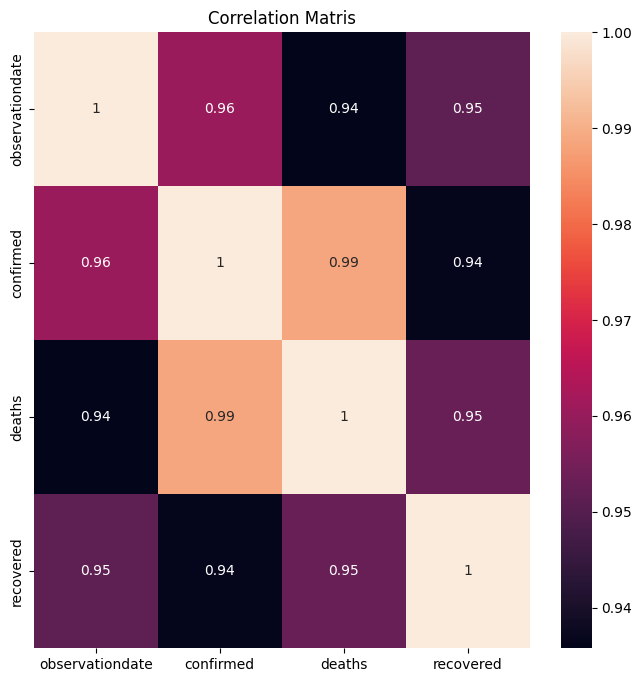

In [755]:
plt.figure(figsize=(8,8))
corr_heatmap=sns.heatmap(covid.corr(),annot=True)
corr_heatmap.set_title('Correlation Matris')
plt.show()

change observation date into numbers

In [756]:
covid['observationdate']=range(1,58)
#Simplifies time-based analysis (e.g., regression models) by replacing dates with sequential integers.

In [757]:
covid.head(5)

,observationdate,confirmed,deaths,recovered
0,1,555.0,17.0,28.0
1,2,653.0,18.0,30.0
2,3,941.0,26.0,36.0
3,4,1438.0,42.0,39.0
4,5,2118.0,56.0,52.0


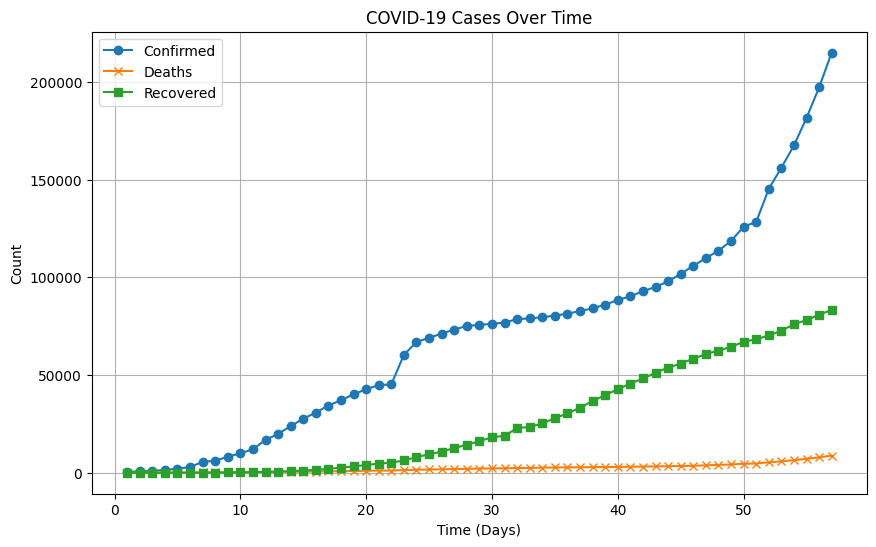

In [758]:
plt.figure(figsize=(10, 6))
plt.plot(covid['observationdate'], covid['confirmed'], label='Confirmed', marker='o')
plt.plot(covid['observationdate'], covid['deaths'], label='Deaths', marker='x')
plt.plot(covid['observationdate'], covid['recovered'], label='Recovered', marker='s')
plt.xlabel('Time (Days)')
plt.ylabel('Count')
plt.title('COVID-19 Cases Over Time')
plt.legend()
plt.grid()
plt.show()

## Feature engineering: Active Cases Calculation

In [759]:
covid['infected'] = covid['confirmed'] - (covid['recovered'] + covid['deaths'])

In [760]:
covid.head(10)

,observationdate,confirmed,deaths,recovered,infected
0,1,555.0,17.0,28.0,510.0
1,2,653.0,18.0,30.0,605.0
2,3,941.0,26.0,36.0,879.0
3,4,1438.0,42.0,39.0,1357.0
4,5,2118.0,56.0,52.0,2010.0
5,6,2927.0,82.0,61.0,2784.0
6,7,5578.0,131.0,107.0,5340.0
7,8,6165.0,133.0,126.0,5906.0
8,9,8235.0,171.0,143.0,7921.0
9,10,9925.0,213.0,222.0,9490.0


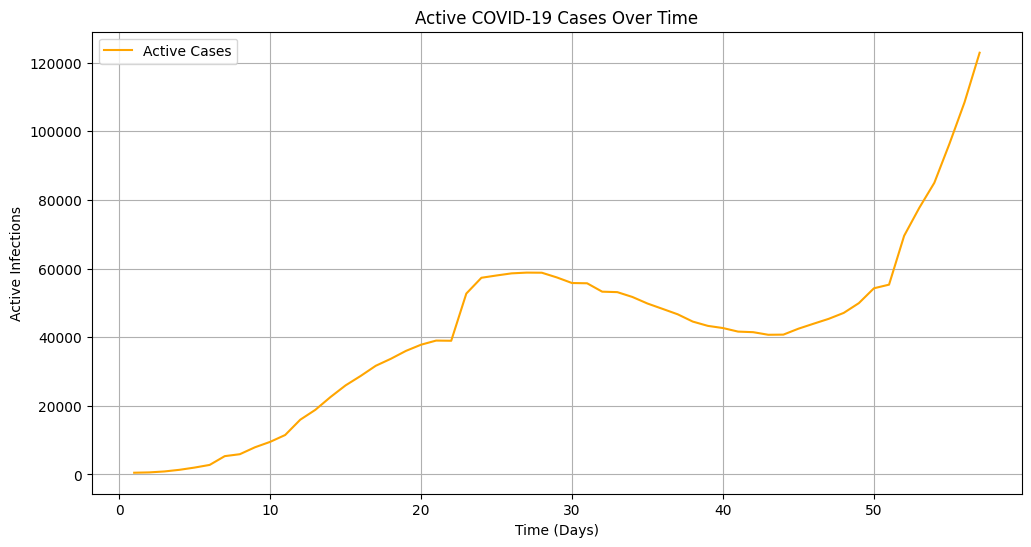

In [761]:
plt.figure(figsize=(12, 6))
plt.plot(covid['observationdate'], covid['infected'], label='Active Cases', color='orange')
plt.xlabel('Time (Days)')
plt.ylabel('Active Infections')
plt.title('Active COVID-19 Cases Over Time')
plt.grid()
plt.legend()
plt.show()

## Deaths prediction


In [762]:
X=covid[['observationdate']]
y=covid['deaths']

In [763]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.12, shuffle=False, random_state=42)
# shuffle shoud be false. it's serial data

In [764]:
X_train.shape

(50, 1)

visualization

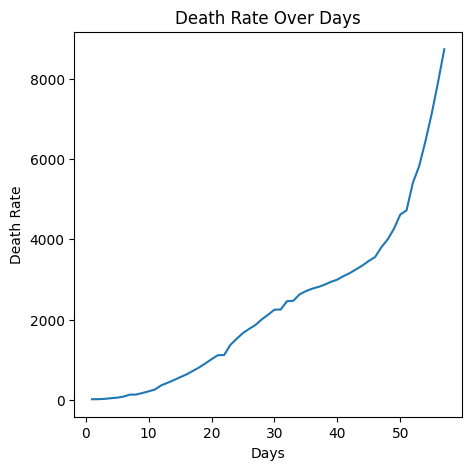

In [765]:
plt.figure(figsize=(5,5))
sns.lineplot(x=covid['observationdate'],y=covid['deaths'])
plt.xlabel('Days')
plt.ylabel('Death Rate')
plt.title('Death Rate Over Days')
plt.show()

create a function for data visualization

In [766]:
def changes_over_days(y_sutun):
    plt.figure(figsize=(5,5))
    sns.lineplot(x=covid['observationdate'],y=covid[y_sutun])
    plt.show()

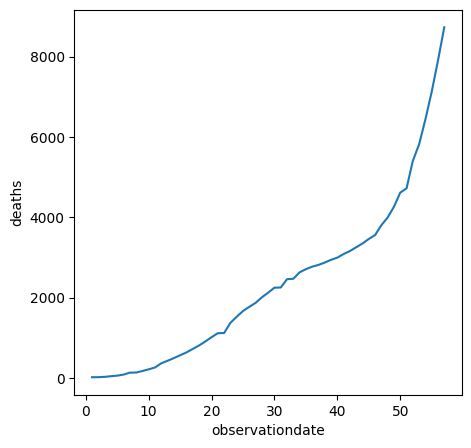

In [767]:
changes_over_days('deaths')

## Model creation


In [768]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
r2_skor = r2_score(y_test, y_pred)
r2_skor

-2.5862765208841862

## Optimize Model

In [769]:
ls_r2_score = []

for i in np.arange(3, 10, 0.01):
    linear_model = LinearRegression()
    linear_model.fit(X_train**i, y_train)
    y_pred = linear_model.predict(X_test**i)
    r2_skor = r2_score(y_test, y_pred)
    ls_r2_score.append((r2_skor,i))

max_r2_score = max(ls_r2_score)
max_r2_score

(0.8614387944952728, np.float64(3.9499999999999797))

In [770]:
linear_model=LinearRegression()
linear_model.fit(X_train**max_r2_score[1], y_train)
y_pred=linear_model.predict(X_test**max_r2_score[1])

## Predicted values

In [771]:
y_pred

array([5538.77459847, 5914.88380541, 6312.9461562 , 6733.79236271,
       7178.26816171, 7647.23430083, 8141.56652476])

In [772]:
linear_model.coef_

array([0.00084888])

In [773]:
linear_model.intercept_

np.float64(820.8771869800626)

In [774]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8614387944952728

Check overfitting

In [775]:
y_pred_train=linear_model.predict(X_train**max_r2_score[1])
r2_score(y_train,y_pred_train)

0.8173819834734685

In [776]:
# pd.concat([y_test.reset_index(drop=True), pd.DataFrame(y_pred, columns=['predicted_deaths']).reset_index(drop=True)], axis=1)
y_pred_covid = pd.DataFrame({"Death":y_test, "predict_death":y_pred})
y_pred_covid

,Death,predict_death
50,4720.0,5538.774598
51,5404.0,5914.883805
52,5819.0,6312.946156
53,6440.0,6733.792363
54,7126.0,7178.268162
55,7905.0,7647.234301
56,8733.0,8141.566525


In [777]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

431.26632270284216

## Visualization

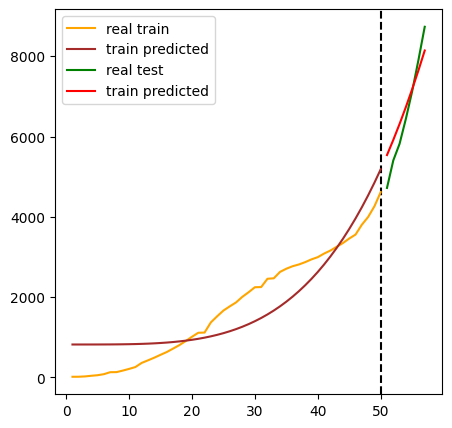

In [778]:
plt.figure(figsize=(5,5))
plt.axvline(50, linestyle='--',color='black')
plt.plot(X_train, y_train, label='real train', color='orange')
plt.plot(X_train, y_pred_train, label='train predicted', color='brown')
plt.plot(X_test, y_test, label='real test', color='green')
plt.plot(X_test, y_pred, label='train predicted', color='red')


plt.legend()
plt.show()

create a function which visualizes predictions

In [779]:
def visualize_estimates():
    plt.figure(figsize=(5,5))
    plt.axvline(50, linestyle='--',color='black')
    plt.plot(X_train, y_train, label='train real', color='orange')
    plt.plot(X_train, y_pred_train, label='train predicted', color='brown')
    plt.plot(X_test, y_test, label='real test', color='green')
    plt.plot(X_test, y_pred, label='train predicted', color='red')
    plt.legend()
    plt.show()

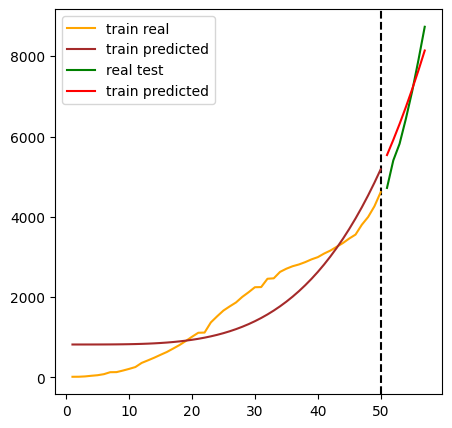

In [780]:
visualize_estimates()

## Recovered texmini

In [781]:
X=covid[['observationdate']]
y=covid['recovered']

In [782]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.12, shuffle=False, random_state=42)

In [783]:
y.head()

,recovered
0,28.0
1,30.0
2,36.0
3,39.0
4,52.0


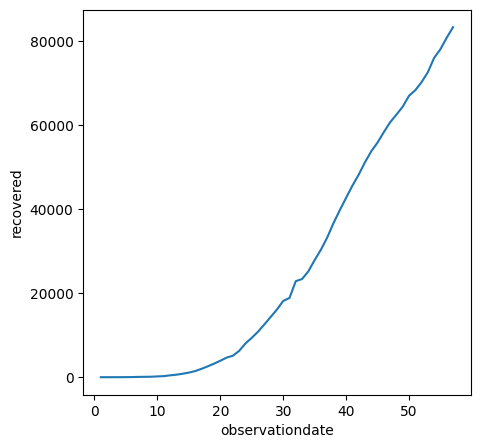

In [784]:
changes_over_days('recovered')

In [785]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [786]:
r2_score(y_test, y_pred)

-8.274909841455694

In [787]:
X_train.head(5)

,observationdate
0,1
1,2
2,3
3,4
4,5


In [788]:
y_train.head(10)

,recovered
0,28.0
1,30.0
2,36.0
3,39.0
4,52.0
5,61.0
6,107.0
7,126.0
8,143.0
9,222.0


In [789]:
ls_r2_score = []

for i in np.arange(1,3,0.01):
    linear_model = LinearRegression()
    linear_model.fit(X_train**i, y_train)
    y_pred = linear_model.predict(X_test**i)
    r2_skor = r2_score(y_test, y_pred)
    ls_r2_score.append((r2_skor,i))

max_r2_score = max(ls_r2_score)
max_r2_score

(0.9918299587942069, np.float64(1.8100000000000007))

In [790]:
linear_model = LinearRegression()
linear_model.fit(X_train**max_r2_score[1], y_train)
y_pred = linear_model.predict(X_test**max_r2_score[1])
r2_skor = r2_score(y_test, y_pred)
r2_skor

0.9918299587942069

In [791]:
mean_absolute_error(y_test, y_pred)

368.00976590559833

In [792]:
y_pred_train=linear_model.predict(X_train**max_r2_score[1])
r2_score(y_train,y_pred_train)

0.9733092858835694

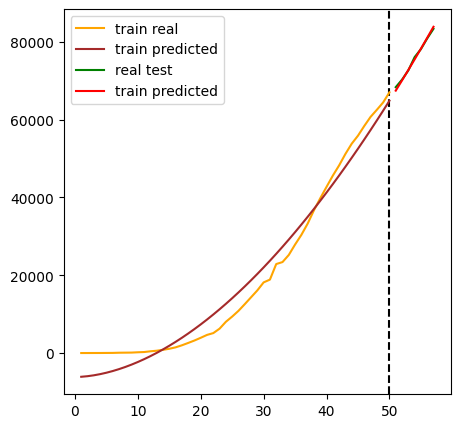

In [793]:
visualize_estimates()

## Confirmed texmini


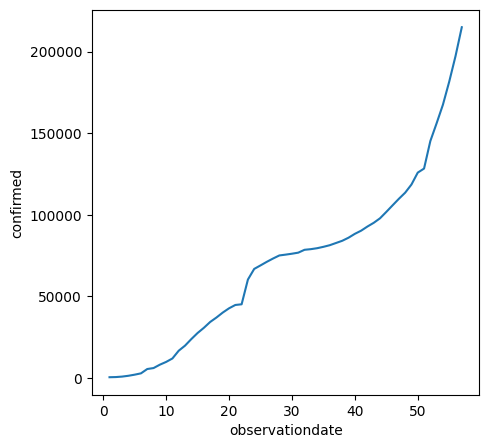

In [794]:
changes_over_days('confirmed')

In [795]:
y=covid['confirmed']

In [796]:
X.head(5)

,observationdate
0,1
1,2
2,3
3,4
4,5


In [797]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.12, shuffle=False, random_state=42)

In [798]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
r2_score_value = r2_score(y_test, y_pred)
r2_score_value

-1.7404685048052597

In [799]:
ls_r2_score = []

for i in np.arange(1,10,0.01):
    linear_model = LinearRegression()
    linear_model.fit(X_train**i, y_train)
    y_pred = linear_model.predict(X_test**i)
    current_r2_score = r2_score(y_test, y_pred)
    ls_r2_score.append((current_r2_score,i))

max_r2_score = max(ls_r2_score)
max_r2_score

(0.8286792380219226, np.float64(3.2100000000000017))

In [800]:
linear_model = LinearRegression()
linear_model.fit(X_train**max_r2_score[1], y_train)
y_pred = linear_model.predict(X_test**max_r2_score[1])
r2_skor = r2_score(y_test, y_pred)
round(r2_skor,2)

0.83

In [801]:
mean_absolute_error(y_test, y_pred)

9805.884311367208

In [802]:
y_pred_train=linear_model.predict(X_train**max_r2_score[1])
r2_score(y_train,y_pred_train)

0.7608572741468528

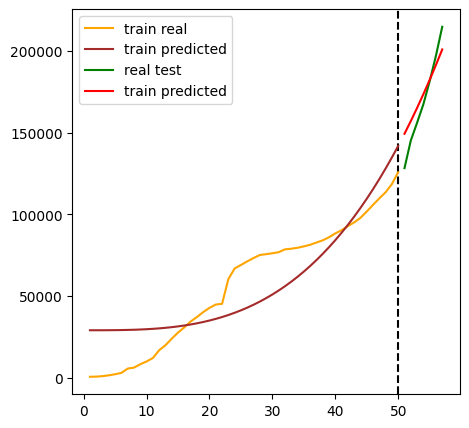

In [803]:
visualize_estimates()

In [804]:
pd.concat([y_test.reset_index(drop=True), pd.DataFrame(y_pred, columns=['predicted']).reset_index(drop=True)], axis=1)

,confirmed,predicted
0,128343.0,149387.713591
1,145193.0,157127.664678
2,156099.0,165203.651695
3,167447.0,173623.509549
4,181546.0,182395.104255
5,197168.0,191526.332482
6,214915.0,201025.121107


## Infected Prediction


In [805]:
X=covid[['observationdate']]
y=covid['infected']

In [806]:
covid.head(5)

,observationdate,confirmed,deaths,recovered,infected
0,1,555.0,17.0,28.0,510.0
1,2,653.0,18.0,30.0,605.0
2,3,941.0,26.0,36.0,879.0
3,4,1438.0,42.0,39.0,1357.0
4,5,2118.0,56.0,52.0,2010.0


In [807]:
X_train=covid.iloc[:50,0]
X_train.head()

,observationdate
0,1
1,2
2,3
3,4
4,5


In [808]:
X_train=covid.iloc[:50,[0]]

In [809]:
X_train.shape

(50, 1)

In [817]:
X_test=covid.iloc[-7:,[0]]

In [818]:
X_test.shape

(7, 1)

In [819]:
y_train=covid.iloc[:50,4]

In [820]:
y_test=covid.iloc[50:,4]

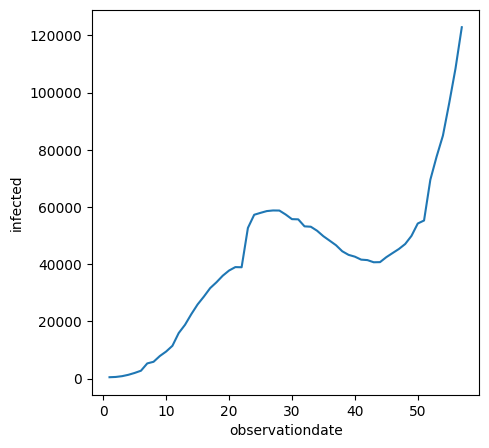

In [821]:
changes_over_days('infected')

In [822]:
linear_model=LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_infected=linear_model.predict(X_test)
y_pred_infected

array([62233.86122449, 63285.21891957, 64336.57661465, 65387.93430972,
       66439.2920048 , 67490.64969988, 68542.00739496])

In [823]:
r2_score(y_test, y_pred_infected)

-0.9106120437965961

In [824]:
ls_r2_score = []

for i in np.arange(1,10,0.01):
    linear_model = LinearRegression()
    linear_model.fit(X_train**i, y_train)
    y_pred = linear_model.predict(X_test**i)
    current_r2_score = r2_score(y_test, y_pred)
    ls_r2_score.append((current_r2_score,i))

best_parameter= max(ls_r2_score)
best_parameter

(0.9815088299950573, np.float64(9.840000000000007))

In [825]:
linear_model = LinearRegression()
linear_model.fit(X_train**best_parameter[1], y_train)
y_pred = linear_model.predict(X_test**best_parameter[1])
y_pred

array([ 62931.27733093,  69256.84383991,  76754.29998852,  85612.31242694,
        96045.52392612, 108297.5477627 , 122644.24273222])

In [826]:
pd.DataFrame({'real':y_test, 'predicted':y_pred})

,real,predicted
50,55299.0,62931.277331
51,69538.0,69256.843840
52,77656.0,76754.299989
53,84973.0,85612.312427
54,96332.0,96045.523926
55,108423.0,108297.547763
56,122869.0,122644.242732


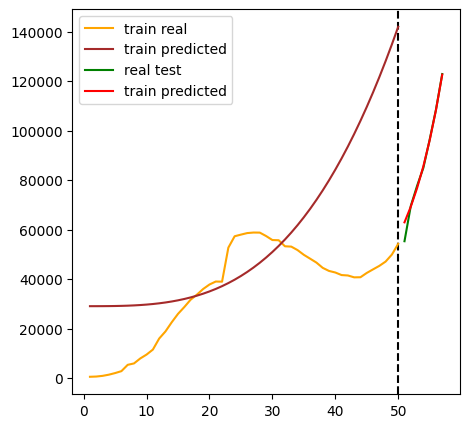

In [828]:
visualize_estimates()

underfit

### **Polynomial regression**

In [829]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)



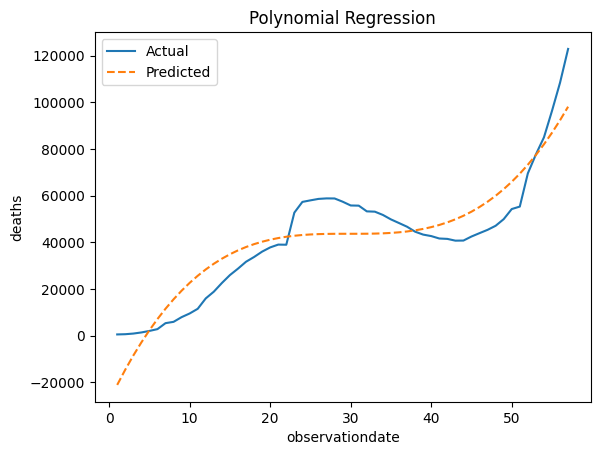

In [830]:
plt.plot(X, y, label='Actual')
plt.plot(X, y_pred, label='Predicted', linestyle='--')
plt.xlabel('observationdate')
plt.ylabel('deaths')
plt.title('Polynomial Regression')
plt.legend()
plt.show()


In [832]:
r2 = r2_score(y, y_pred)
r2

0.833814744196141